## Сверточные нейронные сети 2 (ноутбук)

План семинара:

1. Dropout и Batch Norm
2. Нормализация входных данных
3. Аугментация данных
4. Предобученные модели

In [28]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchvision.transforms.v2 as T
from IPython.display import clear_output
from PIL import Image
from matplotlib import cm
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm, trange
from torchvision.datasets import MNIST

warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

### Dropout

Dropout - это техника регуляризации, которая помогает предотвратить переобучение в нейронных сетях.

Во время обучения случайным образом (обнуляем) некоторые фичи (или целые каналы nn.Dropout1d, nn.Dropout2d)

$$
y = \text{Dropout}(x), \: \text{where} \: x \in \mathbb{R}^d
$$

$$
y_i = \frac{(1 - m_i) x_i}{1 - p}, \: \text{where} \: m_i \sim \text{Bern}(p)
$$

Фактор $\frac{1}{1-p}$ добавляется при обучении, чтобы мы получили несмещенную оценку:
$$
\mathbb{E}[y_i] = \mathbb{E}\bigg[\frac{(1 - m_i) x_i}{1 - p}\bigg] = (1 - p) \mathbb{E}\bigg[\frac{x_i}{1 - p}\bigg] + p * 0 = \mathbb{E}[x_i]
$$

А во время инференса мы "активируем" все нейроны и получаем identity преобразование.

In [29]:
input_dim = 4
x = torch.arange(input_dim, dtype=torch.float32)
model = nn.Dropout(p=0.5)

x

tensor([0., 1., 2., 3.])

In [30]:
model.train()
model(x)

# y = x / (1 - p) = 2x

tensor([0., 2., 4., 6.])

In [31]:
model.eval()
model(x)

tensor([0., 1., 2., 3.])

In [32]:
n_channels = 3
x = torch.arange(n_channels * input_dim, dtype=torch.float32).reshape(n_channels, input_dim)
model = nn.Dropout1d(p=0.5)
x.shape, x

(torch.Size([3, 4]),
 tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]))

Dropout1d зануляет канал целиком (вектор фичей размера 10). Dropout2d в свою очередь занулит целиком канал HxW.

In [33]:
model.train()
model(x)

tensor([[ 0.,  0.,  0.,  0.],
        [ 8., 10., 12., 14.],
        [ 0.,  0.,  0.,  0.]])

### Batch Normalization

Основная идея батч нормы в том, чтобы нормализовать выходы предыдущего слоя перед подачей в следующий слой и стабилизировать распределение активаций во время обучения.

Для каждого батча вычисляется:
$$\mu_B = \frac{1}{m} \sum_{i=1}^m x_i$$

$$\sigma_B^2 = \frac{1}{m} \sum_{i=1}^m (x_i - \mu_B)^2$$

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}$$

$$y_i = \gamma \hat{x}_i + \beta$$

где $\gamma$ (scale) и $\beta$ (shift) - обучаемые параметры.

Во время обучения сохраняем статистики ожидания и дисперсии. На шаге $t$ с моментумом $\alpha$:
$$
\mu_{t} = (1 - \alpha) \mu_{t-1} + \alpha \mu_B
$$
$$
\sigma^2_{t} = (1 - \alpha) \sigma^2_{t-1} + \alpha \frac{m}{m-1} \sigma^2_B
$$

На инференсе нормируем уже с собранными статистиками по датасету после $T$ шагов обучения:
$$
y_i = \gamma \frac{x_i - \mu_T}{\sqrt{\sigma_T^2 + \epsilon}} + \beta
$$

- Позволяет использовать более высокие лернинг рейты, так как градиенты становятся менее чувствительны к скейлу параметров
- Регуляризовывает модель
- Линии уровня функционала становятся более пригодными для стох оптимизации
- Снижает чувствительность к инициализации весов

In [34]:
batch_size = 3
x = torch.arange(batch_size * input_dim, dtype=torch.float32).reshape(batch_size, input_dim)
x.shape, x

(torch.Size([3, 4]),
 tensor([[ 0.,  1.,  2.,  3.],
         [ 4.,  5.,  6.,  7.],
         [ 8.,  9., 10., 11.]]))

nn.BatchNorm1d считает статистики вдоль размерности батча (и опционально по самой последней, если тензор трехмерный)

In [41]:
model = nn.BatchNorm1d(input_dim, affine=False)
model.train()

torch.allclose(model(x), (x - x.mean(0, keepdim=True)) / x.var(0, keepdim=True, unbiased=False).sqrt(), atol=1e-6)

True

In [42]:
seq_len = 2
x = torch.arange(batch_size * input_dim * seq_len, dtype=torch.float32).reshape(batch_size, input_dim, seq_len)
x.shape, x

(torch.Size([3, 4, 2]),
 tensor([[[ 0.,  1.],
          [ 2.,  3.],
          [ 4.,  5.],
          [ 6.,  7.]],
 
         [[ 8.,  9.],
          [10., 11.],
          [12., 13.],
          [14., 15.]],
 
         [[16., 17.],
          [18., 19.],
          [20., 21.],
          [22., 23.]]]))

In [44]:
model = nn.BatchNorm1d(input_dim, affine=False)
model.train()

torch.allclose(model(x), (x - x.mean((0,2), keepdim=True)) / x.var((0,2), keepdim=True, unbiased=False).sqrt(), atol=1e-6)

True

In [45]:
n_channels, height, width = 2, 2, 2
x = torch.arange(batch_size * n_channels * height * width, dtype=torch.float32).reshape(batch_size, n_channels, height, width)
x.shape

torch.Size([3, 2, 2, 2])

In [46]:
model = nn.BatchNorm2d(n_channels, affine=False)
model.train()

torch.allclose(model(x), (x - x.mean((0,2,3), keepdim=True)) / x.var((0,2,3), keepdim=True, unbiased=False).sqrt(), atol=1e-6)

True

In [54]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset

torch.manual_seed(42)
np.random.seed(42)

X, y = make_classification(n_samples=10000, n_features=100, n_informative=80,
                          n_redundant=20, n_clusters_per_class=2,
                          random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

In [55]:
class NeuralNet(nn.Module):
    def __init__(self, use_batchnorm=False):
        super().__init__()
        self.use_batchnorm = use_batchnorm

        self.fc1 = nn.Linear(100, 100)
        self.fc2 = nn.Linear(100, 50)
        self.fc3 = nn.Linear(50, 2)

        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(100)
            self.bn2 = nn.BatchNorm1d(50)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)
model_without_bn = NeuralNet(use_batchnorm=False).to(device)
model_with_bn = NeuralNet(use_batchnorm=True).to(device)

cuda:0


In [56]:
def train_model(model, train_loader, X_test, y_test, device, epochs=100, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    gradients_norm = []

    xrange = trange(epochs)
    for epoch in xrange:
        # Training
        model.train()
        epoch_loss = 0
        correct = 0
        total = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X.to(device))
            loss = criterion(outputs, batch_y.to(device))
            loss.backward()

            # Track gradient norm
            total_norm = 0
            for p in model.parameters():
                if p.grad is not None:
                    param_norm = p.grad.data.norm(2)
                    total_norm += param_norm.item() ** 2
            total_norm = total_norm ** 0.5
            gradients_norm.append(total_norm)

            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y.to(device)).sum().item()

        train_accuracy = correct / total

        # Evaluation
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test.to(device))
            test_loss = criterion(test_outputs, y_test.to(device))
            _, test_predicted = torch.max(test_outputs.data, 1)
            test_accuracy = (test_predicted == y_test.to(device)).float().mean().item()

        train_losses.append(epoch_loss / len(train_loader))
        test_losses.append(test_loss.item())
        train_accuracies.append(train_accuracy)
        test_accuracies.append(test_accuracy)

        xrange.set_description_str(
            f'Epoch {epoch}: Train Loss: {epoch_loss/len(train_loader):.4f}, '
            f'Test Loss: {test_loss.item():.4f}, '
            f'Train Acc: {train_accuracy:.4f}, Test Acc: {test_accuracy:.4f}'
        )


    return train_losses, test_losses, train_accuracies, test_accuracies, gradients_norm

torch.manual_seed(42)
np.random.seed(42)

print("Обучение модели без BatchNorm:")
train_loss_no_bn, test_loss_no_bn, train_acc_no_bn, test_acc_no_bn, grad_norm_no_bn = train_model(
    model_without_bn, train_loader, X_test_tensor, y_test_tensor, device)

print("Обучение модели с BatchNorm:")
train_loss_with_bn, test_loss_with_bn, train_acc_with_bn, test_acc_with_bn, grad_norm_with_bn = train_model(
    model_with_bn, train_loader, X_test_tensor, y_test_tensor, device)

Обучение модели без BatchNorm:


  0%|          | 0/100 [00:00<?, ?it/s]

Обучение модели с BatchNorm:


  0%|          | 0/100 [00:00<?, ?it/s]

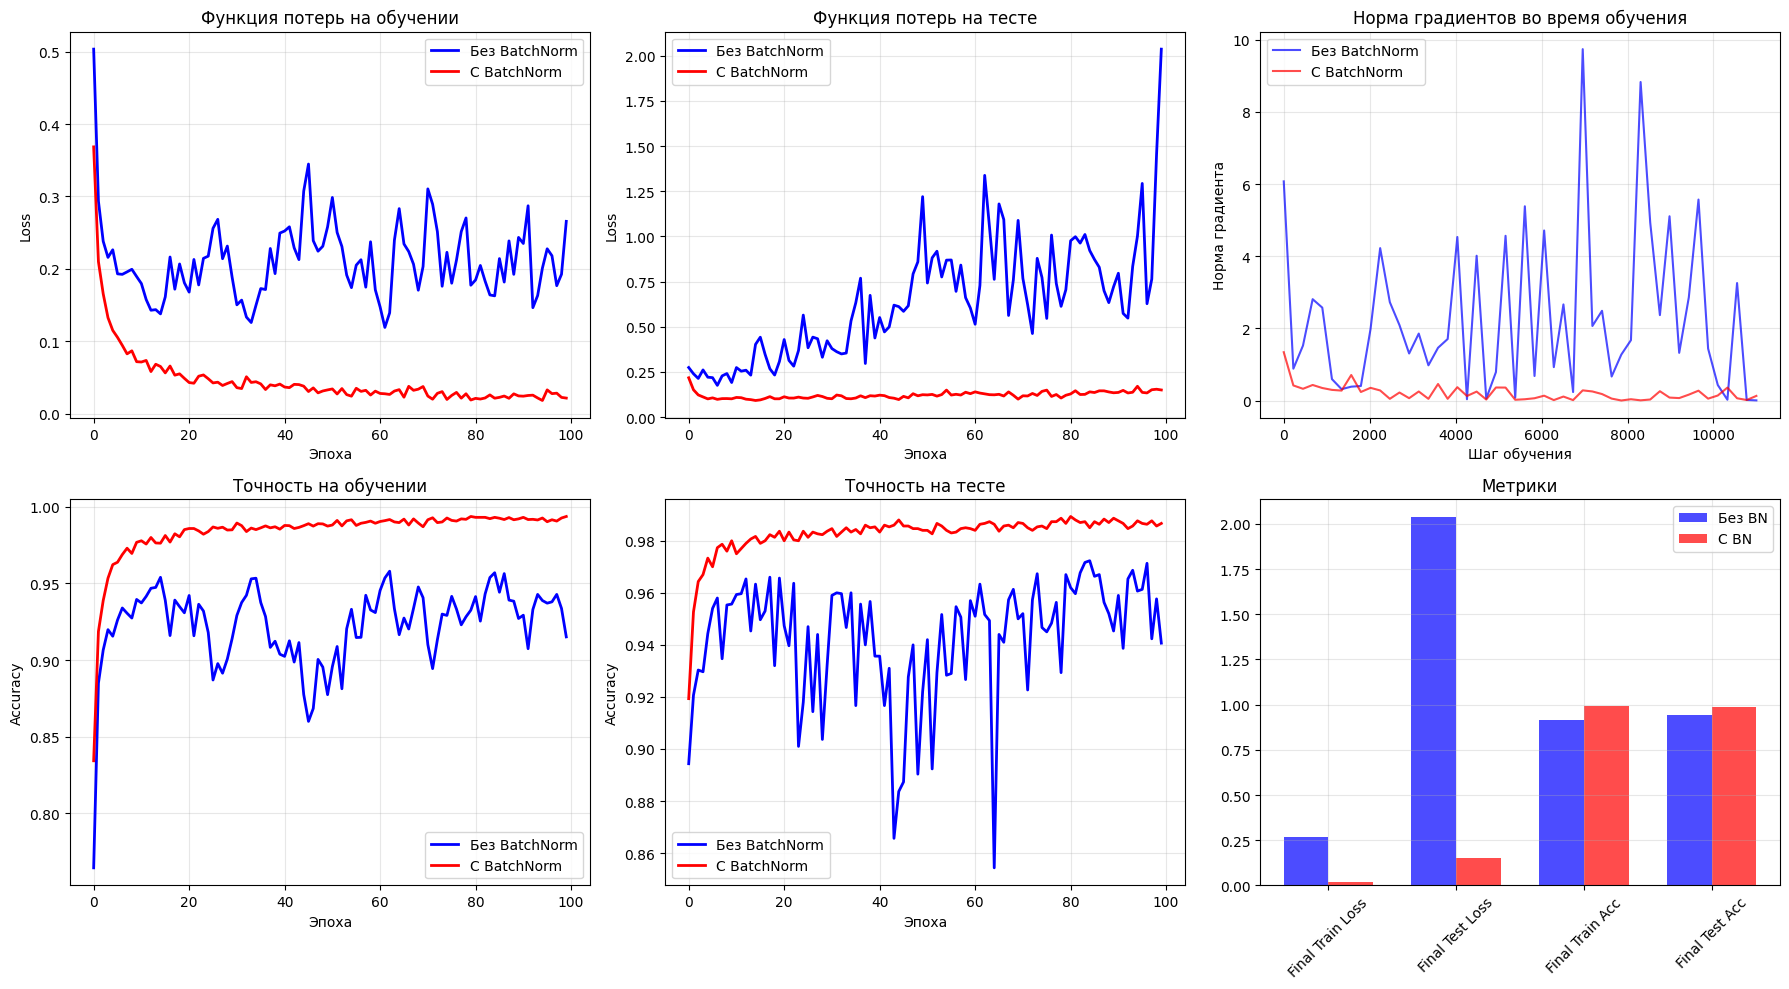

In [57]:
# Plot comprehensive results
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss comparison
epochs_range = range(len(train_loss_no_bn))

axes[0, 0].plot(epochs_range, train_loss_no_bn, 'b-', label='Без BatchNorm', linewidth=2)
axes[0, 0].plot(epochs_range, train_loss_with_bn, 'r-', label='С BatchNorm', linewidth=2)
axes[0, 0].set_title('Функция потерь на обучении')
axes[0, 0].set_xlabel('Эпоха')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(epochs_range, test_loss_no_bn, 'b-', label='Без BatchNorm', linewidth=2)
axes[0, 1].plot(epochs_range, test_loss_with_bn, 'r-', label='С BatchNorm', linewidth=2)
axes[0, 1].set_title('Функция потерь на тесте')
axes[0, 1].set_xlabel('Эпоха')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Accuracy comparison
axes[1, 0].plot(epochs_range, train_acc_no_bn, 'b-', label='Без BatchNorm', linewidth=2)
axes[1, 0].plot(epochs_range, train_acc_with_bn, 'r-', label='С BatchNorm', linewidth=2)
axes[1, 0].set_title('Точность на обучении')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_range, test_acc_no_bn, 'b-', label='Без BatchNorm', linewidth=2)
axes[1, 1].plot(epochs_range, test_acc_with_bn, 'r-', label='С BatchNorm', linewidth=2)
axes[1, 1].set_title('Точность на тесте')
axes[1, 1].set_xlabel('Эпоха')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Gradient norms comparison
grad_epochs_no_bn = np.linspace(0, len(grad_norm_no_bn)-1, 50).astype(int)
grad_epochs_with_bn = np.linspace(0, len(grad_norm_with_bn)-1, 50).astype(int)

axes[0, 2].plot(grad_epochs_no_bn, [grad_norm_no_bn[i] for i in grad_epochs_no_bn],
                'b-', label='Без BatchNorm', alpha=0.7)
axes[0, 2].plot(grad_epochs_with_bn, [grad_norm_with_bn[i] for i in grad_epochs_with_bn],
                'r-', label='С BatchNorm', alpha=0.7)
axes[0, 2].set_title('Норма градиентов во время обучения')
axes[0, 2].set_xlabel('Шаг обучения')
axes[0, 2].set_ylabel('Норма градиента')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Final comparison bar chart
final_metrics = {
    'Final Train Loss': [train_loss_no_bn[-1], train_loss_with_bn[-1]],
    'Final Test Loss': [test_loss_no_bn[-1], test_loss_with_bn[-1]],
    'Final Train Acc': [train_acc_no_bn[-1], train_acc_with_bn[-1]],
    'Final Test Acc': [test_acc_no_bn[-1], test_acc_with_bn[-1]]
}

x = np.arange(len(final_metrics))
width = 0.35

for i, (metric_name, values) in enumerate(final_metrics.items()):
    axes[1, 2].bar(i - width/2, values[0], width, label='Без BN' if i == 0 else "", color='blue', alpha=0.7)
    axes[1, 2].bar(i + width/2, values[1], width, label='С BN' if i == 0 else "", color='red', alpha=0.7)

axes[1, 2].set_title('Метрики')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(list(final_metrics.keys()), rotation=45)
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Нормализация входных данных

Хорошая практика в глубинном обучении - нормализовать входные данные.

In [58]:
mnist_train = MNIST('datasets/mnist', transform=T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]), download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.94MB/s]


In [59]:
mnist_train.data.dtype, mnist_train.data.min(), mnist_train.data.max()

(torch.uint8, tensor(0, dtype=torch.uint8), tensor(255, dtype=torch.uint8))

In [60]:
mean = mnist_train.data.to(torch.float32).mean().item() / 255

mean

0.13066047219669116

In [61]:
std = mnist_train.data.to(torch.float32).std().item() / 255

std

0.30810780244715075

In [62]:
normalize = T.Normalize(mean=(mean,), std=(std,))

In [63]:
normalize(mnist_train.data.to(torch.float32) / 255).mean()

tensor(2.9651e-08)

In [64]:
normalize(mnist_train.data.to(torch.float32) / 255).std()

tensor(1.0000)

### Аугментация данных

https://pytorch.org/vision/stable/transforms.html

https://pytorch.org/vision/stable/auto_examples/plot_transforms.html#sphx-glr-auto-examples-plot-transforms-py

In [65]:
from torchvision.datasets import CIFAR10

In [67]:
dataset_train = CIFAR10('datasets/cifar', train=True, download=True, transform=T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)]))

100%|██████████| 170M/170M [00:04<00:00, 38.5MB/s]


In [68]:
dataset_train.class_to_idx

{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [69]:
dataset_train[0][0]

Image([[[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
        [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
        [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
        ...,
        [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
        [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
        [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]],

       [[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
        [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
        [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
        ...,
        [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
        [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
        [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]],

       [[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
        [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
        [0.0824, 0.0000, 0.0314,  ..., 0.1961, 0.1961, 0.1647],
        ..

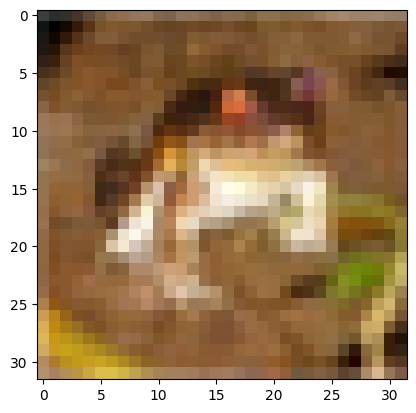

In [70]:
plt.imshow(dataset_train[0][0].permute(1,2,0))
plt.show()

In [71]:
dataset_train.data.shape

(50000, 32, 32, 3)

In [72]:
means = (dataset_train.data / 255).mean(axis=(0, 1, 2))

means

array([0.49139968, 0.48215841, 0.44653091])

In [73]:
stds = (dataset_train.data / 255).std(axis=(0, 1, 2))

stds

array([0.24703223, 0.24348513, 0.26158784])

In [74]:
transform = T.Compose(
    [
        T.ToImage(),
        T.ToDtype(torch.float32, scale=True),
        T.Normalize(mean=means, std=stds)
    ]
)

In [75]:
train_dataset = CIFAR10('datasets/cifar', train=True, transform=transform)
valid_dataset = CIFAR10('datasets/cifar', train=False, transform=transform)

In [76]:
train_images = []
for i in trange(len(train_dataset)):
    train_images += [train_dataset[i][0]]
train_images = torch.stack(train_images, dim=0)
train_images.shape

  0%|          | 0/50000 [00:00<?, ?it/s]

torch.Size([50000, 3, 32, 32])

In [77]:
train_images.mean((0, 2, 3)), train_images.std((0, 2, 3))

(tensor([1.2557e-07, 4.3178e-08, 1.2714e-07]),
 tensor([1.0000, 1.0000, 1.0000]))

In [78]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [79]:
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Optimizer
from tqdm import tqdm


def train(model: nn.Module, data_loader: DataLoader, optimizer: Optimizer, loss_fn, device: torch.device):
    model.train()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        output = model(x)

        loss = loss_fn(output, y)

        loss.backward()

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

        optimizer.step()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [80]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def evaluate(model: nn.Module, data_loader: DataLoader, loss_fn, device: torch.device):
    model.eval()

    total_loss = 0
    total_correct = 0

    for x, y in tqdm(data_loader):
        x, y = x.to(device), y.to(device)

        output = model(x)

        loss = loss_fn(output, y)

        total_loss += loss.item()

        total_correct += (output.argmax(dim=1) == y).sum().item()

    return total_loss / len(data_loader), total_correct / len(data_loader.dataset)

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style='darkgrid')


def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    train_accuracy: list[float],
    valid_accuracy: list[float],
    title: str
):
    plt.figure(figsize=(16, 8))

    plt.title(title + ' loss')

    plt.plot(train_loss, label='Train loss')
    plt.plot(valid_loss, label='Valid loss')
    plt.legend()

    plt.show()

    plt.figure(figsize=(16, 8))

    plt.title(title + ' accuracy')

    plt.plot(train_accuracy, label='Train accuracy')
    plt.plot(valid_accuracy, label='Valid accuracy')
    plt.legend()

    plt.show()

In [87]:
from IPython.display import clear_output
import os


def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []
    os.makedirs("checkpoints", exist_ok=True)

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        torch.save(model.state_dict(), f"checkpoints/model_{epoch}.pt")
        torch.save(optimizer.state_dict(), f"checkpoints/optimizer_{epoch}.pt")

In [88]:
from torch import nn


class FirstModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),  # 16 x 32 x 32
            nn.ReLU(),

            nn.MaxPool2d(2),  # 16 x 16 x 16

            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),  # 32 x 16 x 16
            nn.ReLU(),

            nn.MaxPool2d(2),  # 32 x 8 x 8

            nn.Flatten(),

            nn.Linear(32 * 8 * 8, 1024),
            nn.ReLU(),
            nn.Linear(1024, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.net(x)

In [89]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)

loss_fn = nn.CrossEntropyLoss()

cuda:0


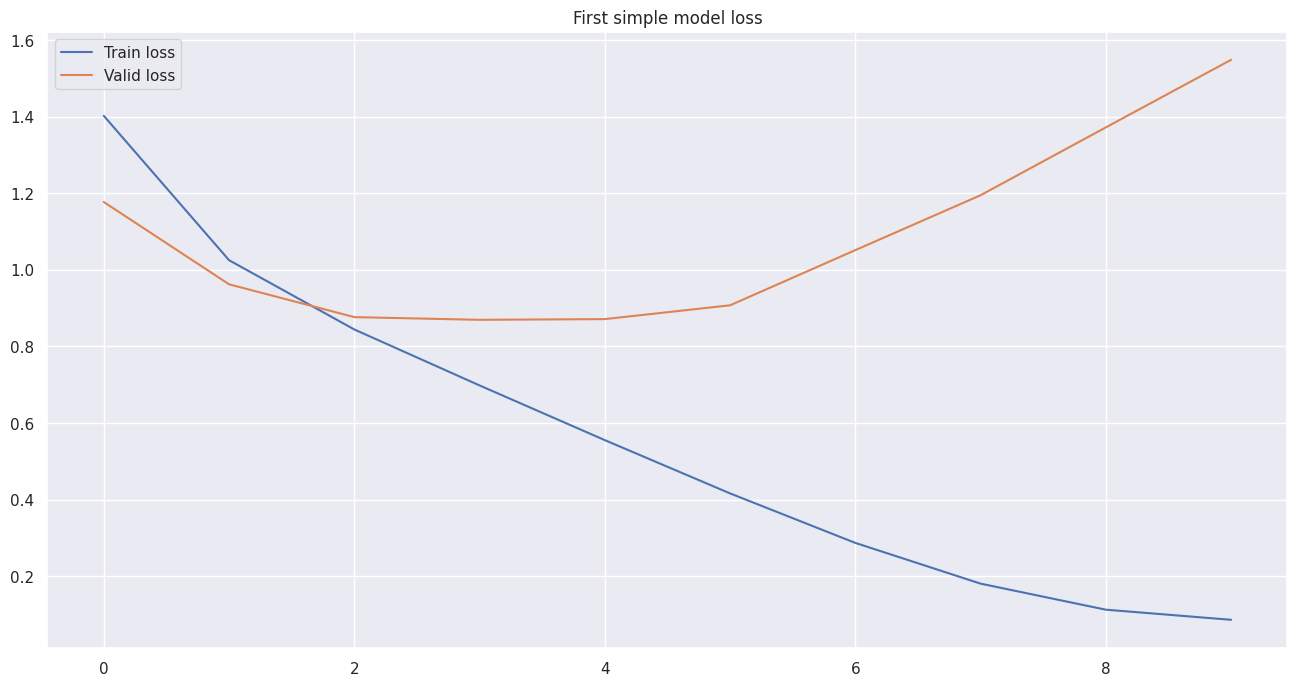

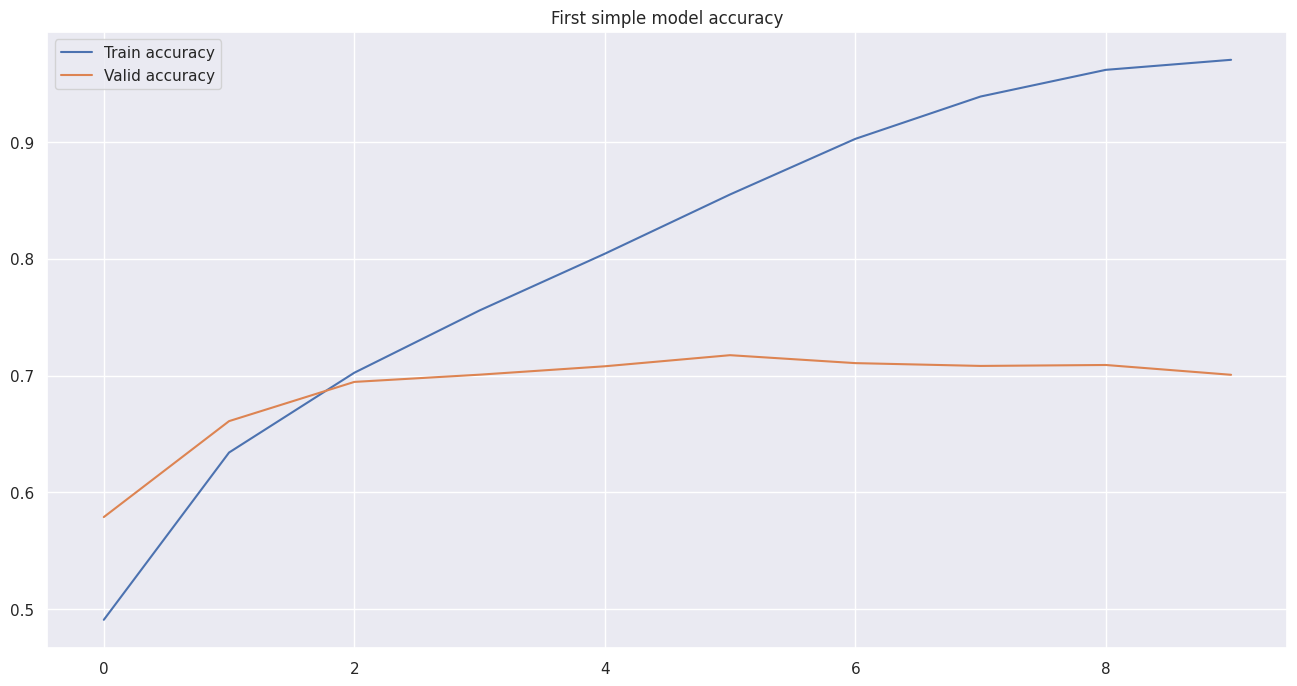

In [90]:
from torch.optim import Adam

torch.manual_seed(42)
np.random.seed(42)

model = FirstModel().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 10, 'First simple model')

Сделаем сетку глубже и шире, увеличивая количество каналов и уменьшая пространственную размерность HxW

In [91]:
class SecondModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.ReLU(),

            nn.MaxPool2d(2),  # 32 x 16 x 16

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),  # 64 x 16 x 16
            nn.ReLU(),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),  # 64 x 16 x 16
            nn.ReLU(),

            nn.MaxPool2d(2),  # 64 x 8 x 8

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),  # 128 x 8 x 8
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),  # 128 x 8 x 8
            nn.ReLU(),

            nn.MaxPool2d(2),  # 128 x 4 x 4

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

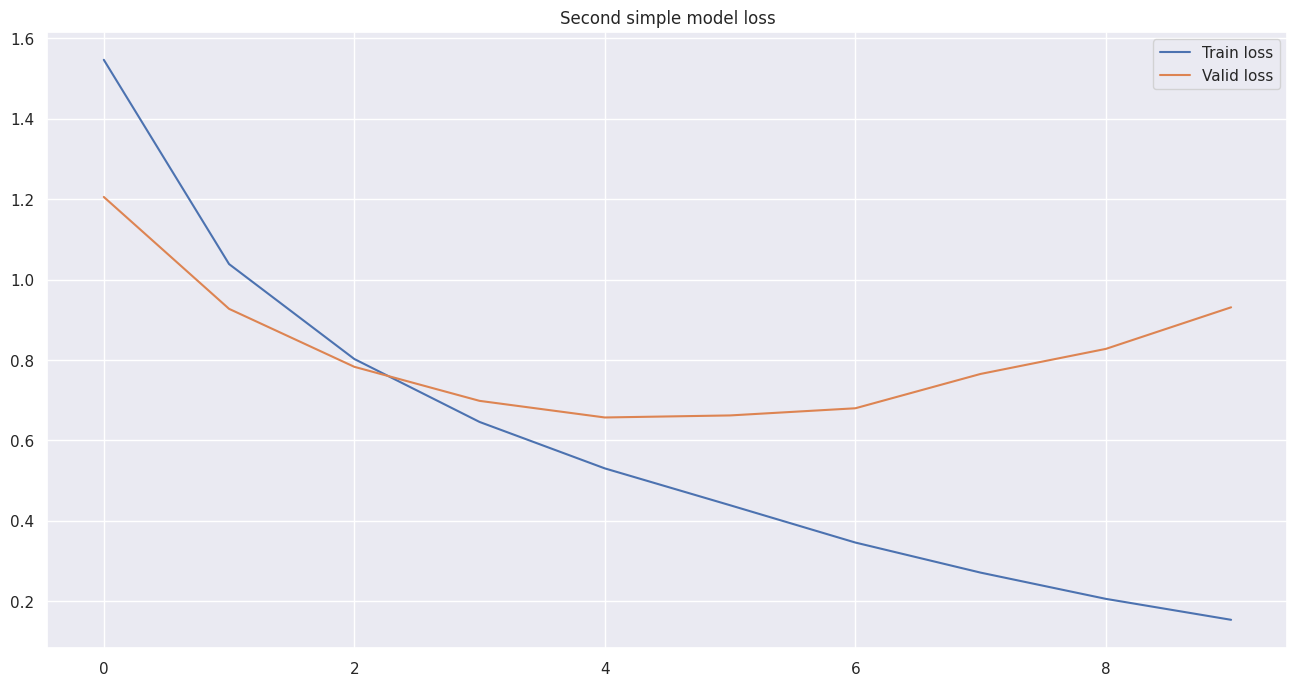

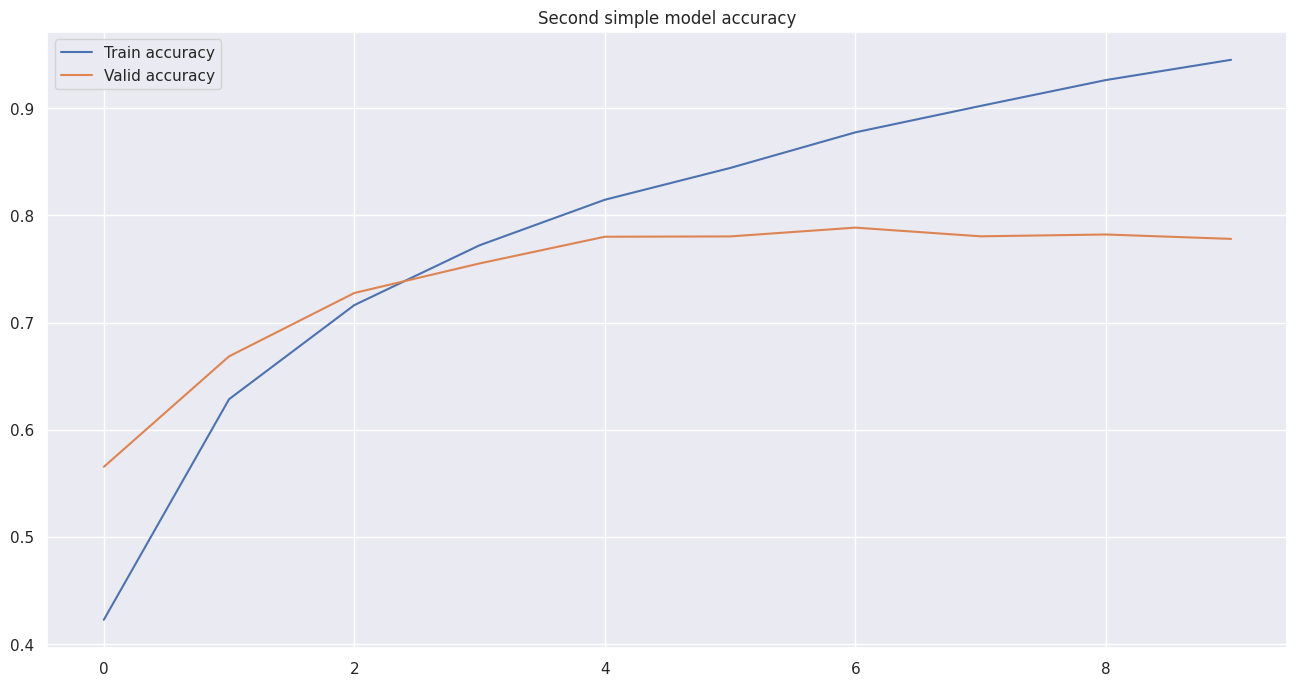

In [92]:
torch.manual_seed(42)
np.random.seed(42)

model = SecondModel().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 10, 'Second simple model')

Добавим батч норму.

In [93]:
class ThirdModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 32 x 16 x 16

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),  # 64 x 16 x 16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),  # 64 x 16 x 16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 64 x 8 x 8

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),  # 128 x 8 x 8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),  # 128 x 8 x 8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 128 x 4 x 4

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

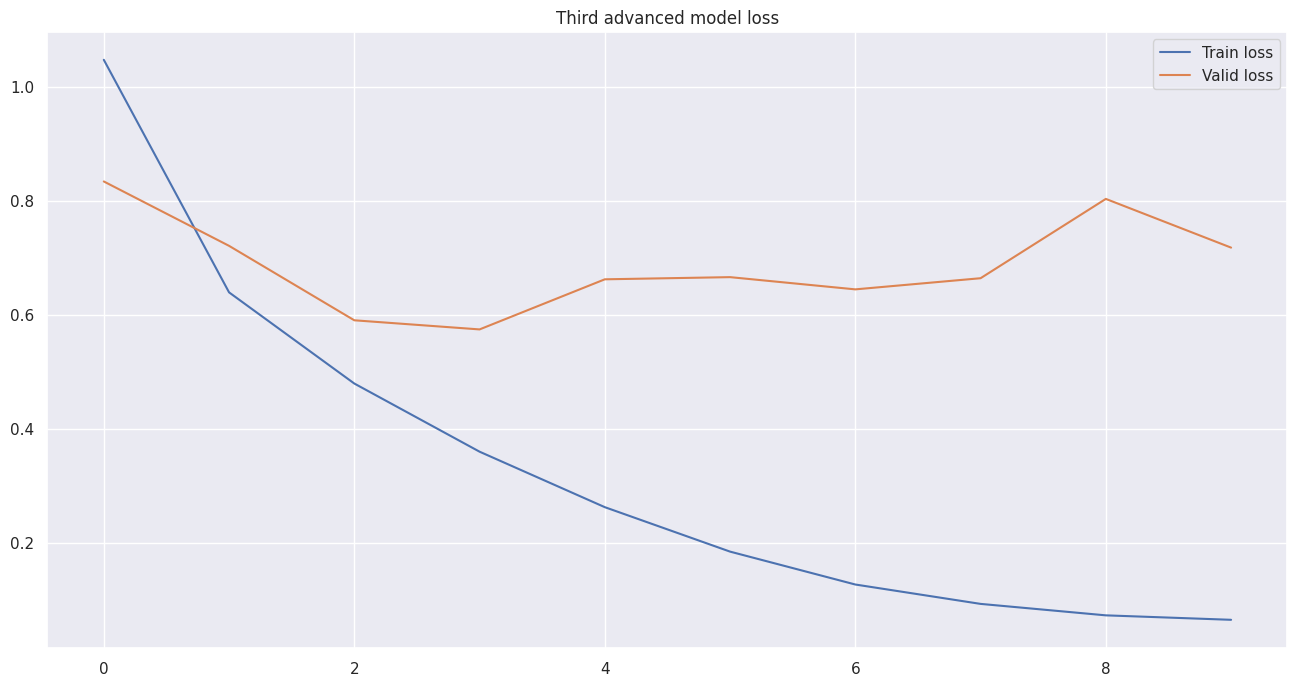

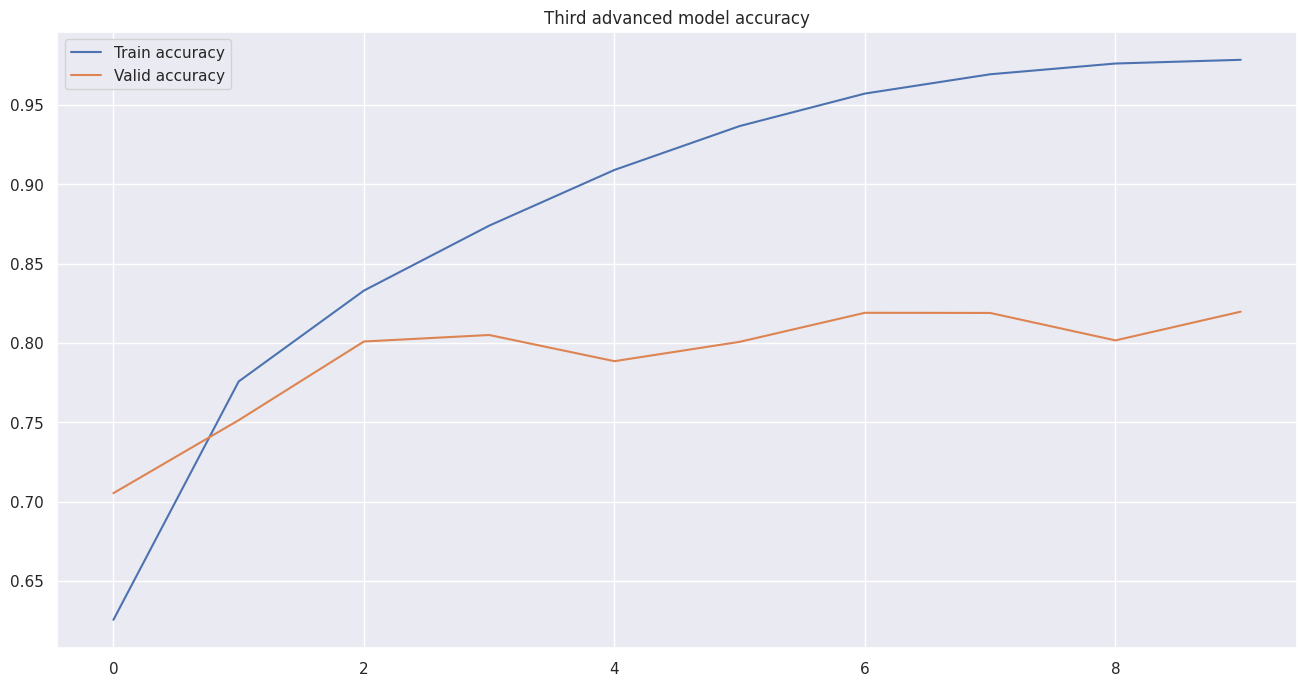

In [94]:
torch.manual_seed(42)
np.random.seed(42)

model = ThirdModel().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 10, 'Third advanced model')

Добавим dropout.

In [95]:
class FourthModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),  # 32 x 32 x 32
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 32 x 16 x 16
            nn.Dropout2d(p=0.2),

            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),  # 64 x 16 x 16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),  # 64 x 16 x 16
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 32 x 8 x 8
            nn.Dropout2d(p=0.2),

            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),  # 128 x 8 x 8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding=1),  # 128 x 8 x 8
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.MaxPool2d(2),  # 128 x 4 x 4
            nn.Dropout2d(p=0.2),

            nn.Flatten(),

            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.net(x)

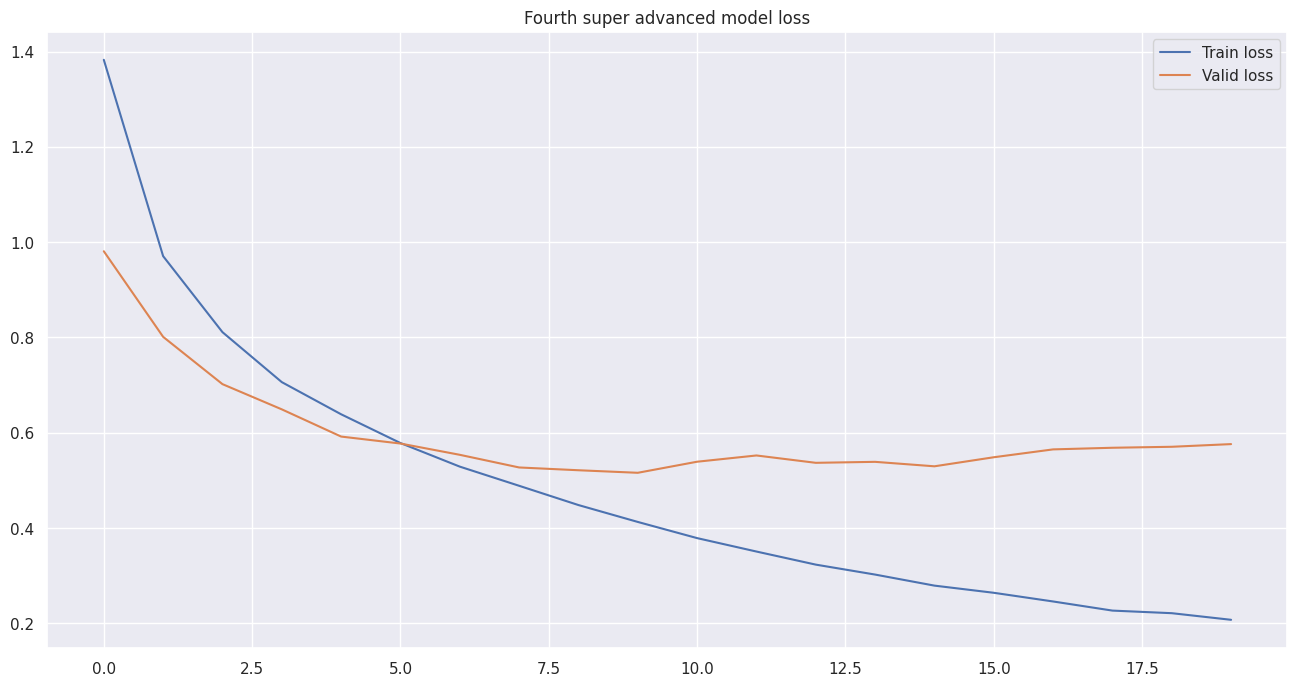

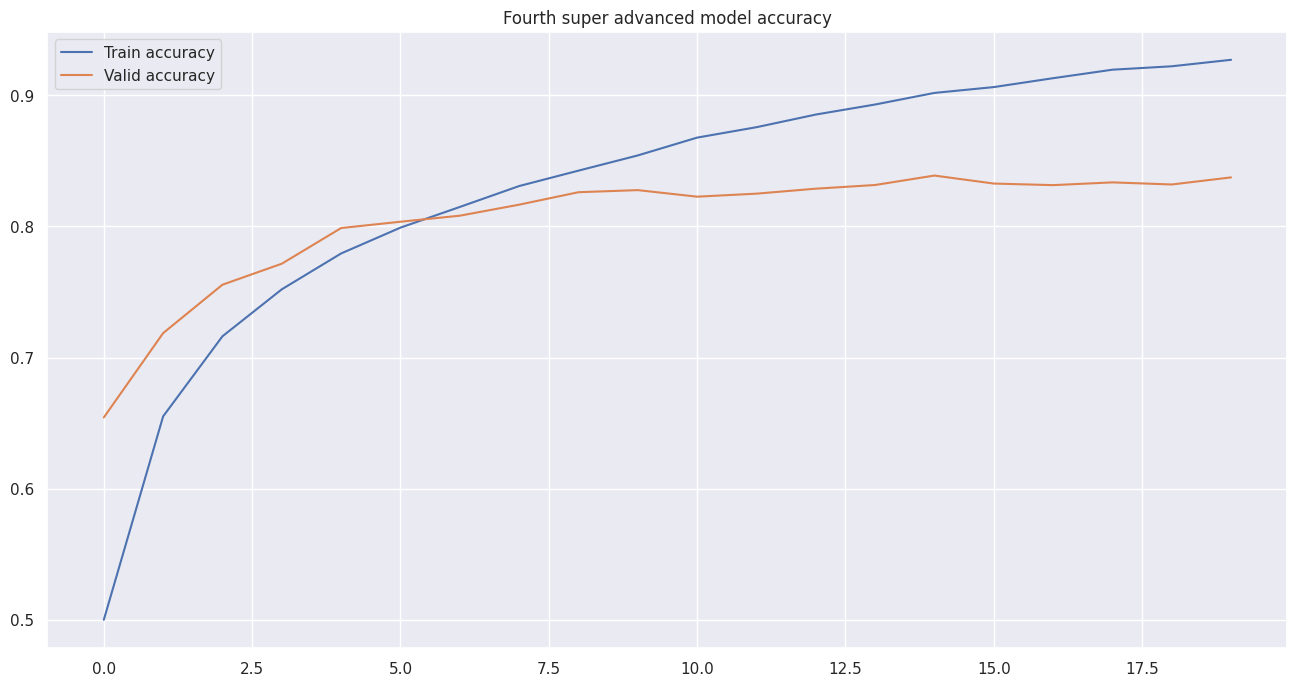

In [96]:
torch.manual_seed(42)
np.random.seed(42)

model = FourthModel().to(device)
optimizer = Adam(model.parameters(), lr=1e-3)
fit(model, train_loader, valid_loader, optimizer, loss_fn, device, 20, 'Fourth super advanced model')

In [97]:
train_transforms = T.Compose(
    [
        T.RandomResizedCrop(size=32, scale=(0.8, 1.1)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomAdjustSharpness(sharpness_factor=2),
        T.ToTensor(),
        T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]
)

test_transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]
)

train_dataset = CIFAR10('datasets/cifar', train=True, transform=train_transforms)
valid_dataset = CIFAR10('datasets/cifar', train=False, transform=test_transforms)

train_loader_augs1 = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader_augs1 = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

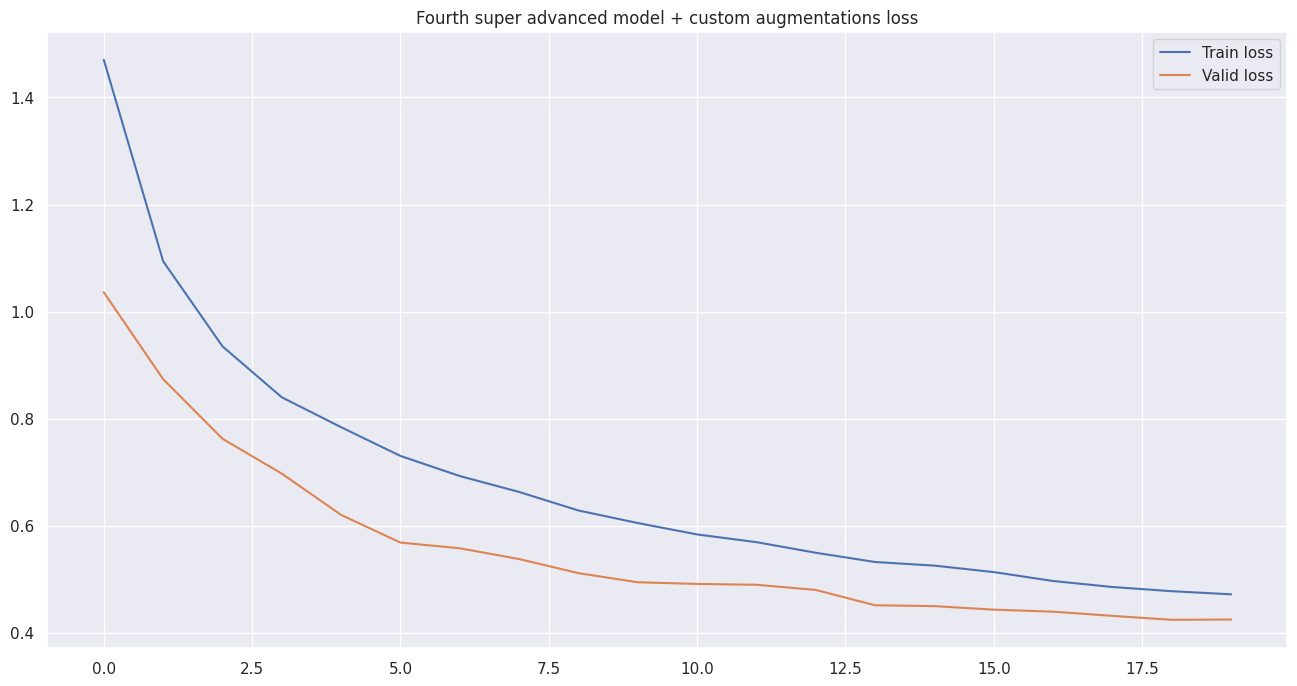

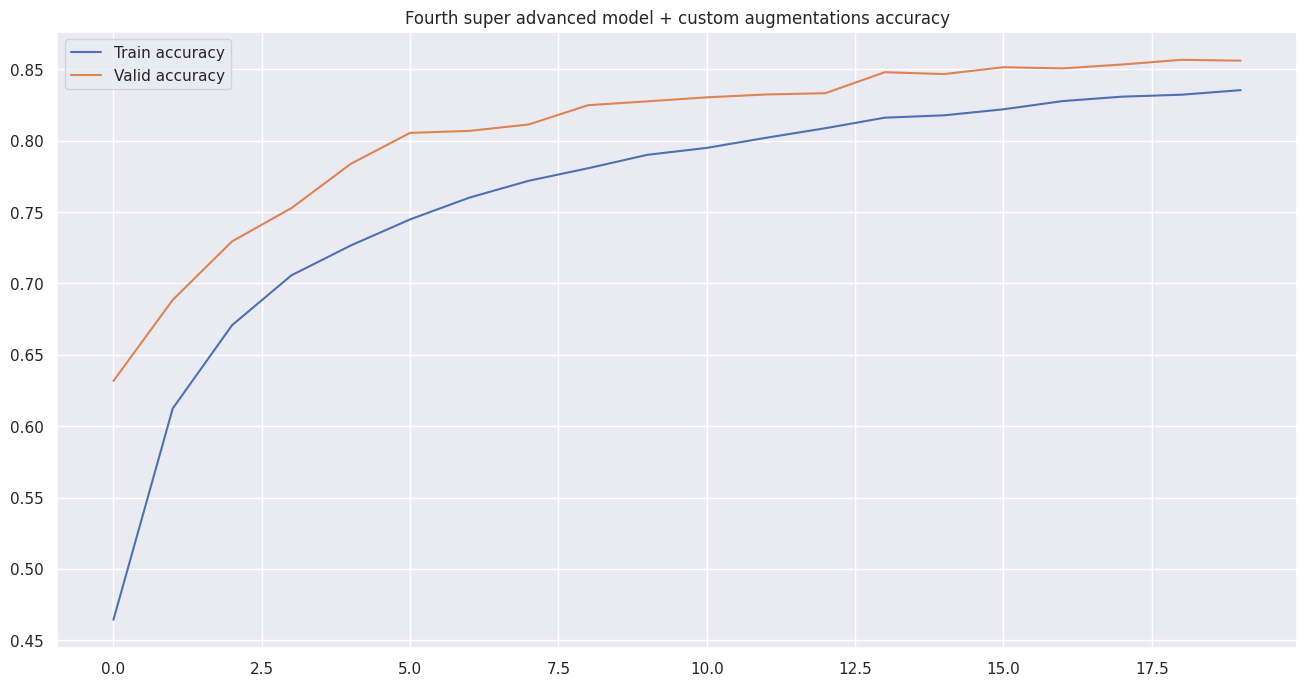

In [98]:
torch.manual_seed(42)
np.random.seed(42)

model = FourthModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(
    model,
    train_loader_augs1, valid_loader_augs1,
    optimizer, loss_fn, device, 20, 'Fourth super advanced model + custom augmentations'
)

In [111]:
train_transforms = T.Compose(
    [
        T.AutoAugment(T.AutoAugmentPolicy.CIFAR10),
        T.ToTensor(),
        T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]
)

test_transforms = T.Compose(
    [
        T.ToTensor(),
        T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]
)

train_dataset = CIFAR10('datasets/cifar', train=True, transform=train_transforms)
valid_dataset = CIFAR10('datasets/cifar', train=False, transform=test_transforms)

train_loader_augs2 = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader_augs2 = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

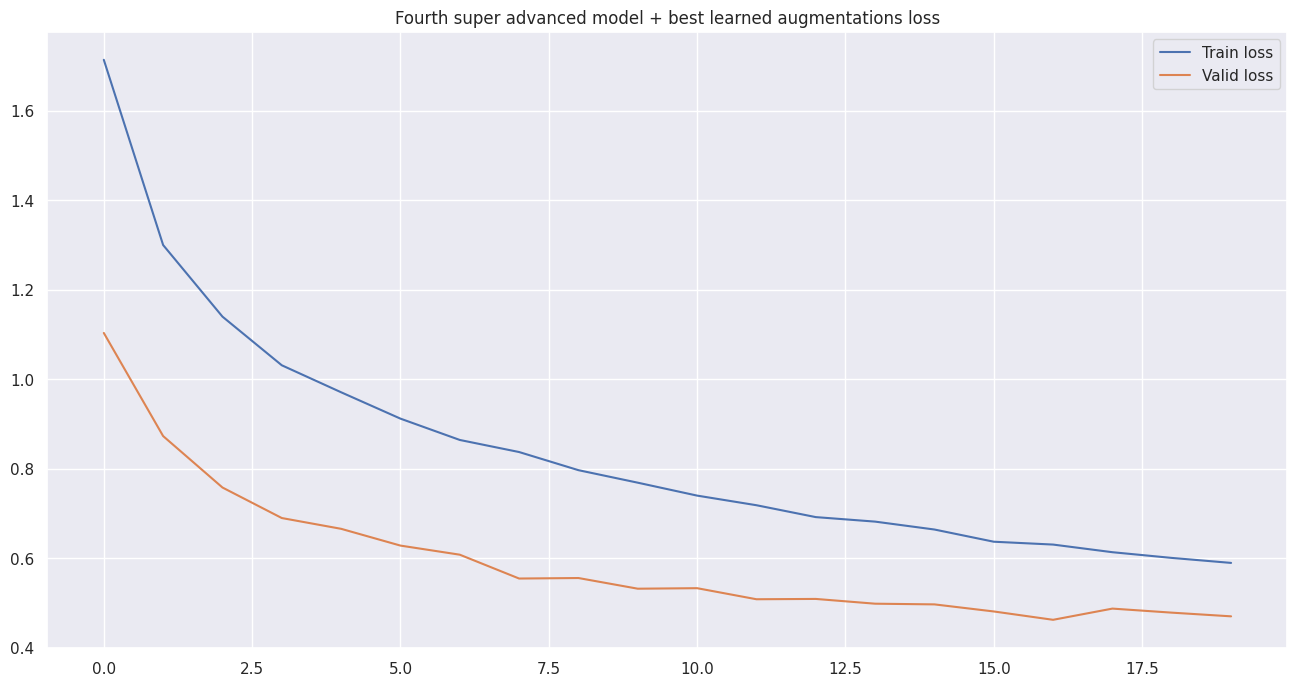

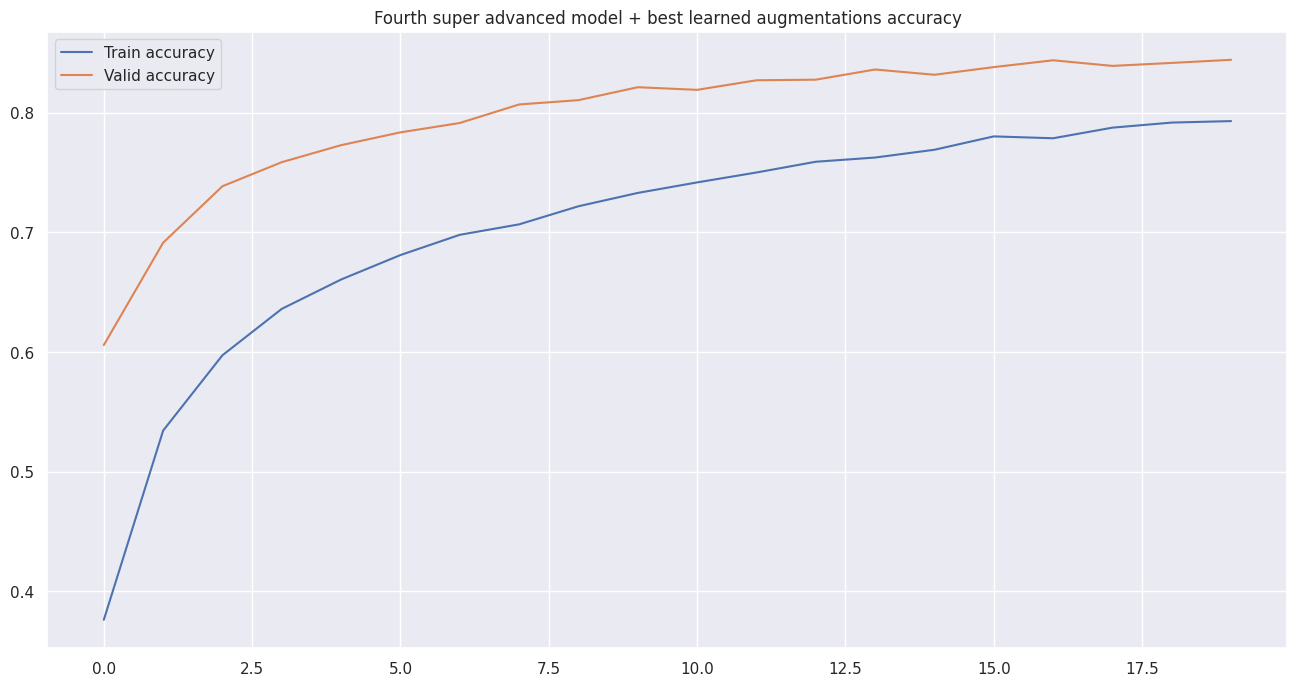

In [100]:
torch.manual_seed(42)
np.random.seed(42)
model = FourthModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

fit(
    model,
    train_loader_augs2, valid_loader_augs2,
    optimizer, loss_fn, device, 20, 'Fourth super advanced model + best learned augmentations'
)

In [112]:
# https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate

def fit(model, train_loader, valid_loader, optimizer, loss_fn, device, num_epochs, title, scheduler=None):
    train_loss_history, valid_loss_history = [], []
    train_accuracy_history, valid_accuracy_history = [], []

    for epoch in range(num_epochs):
        train_loss, train_accuracy = train(model, train_loader, optimizer, loss_fn, device)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, loss_fn, device)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        train_accuracy_history.append(train_accuracy)
        valid_accuracy_history.append(valid_accuracy)

        clear_output()

        plot_stats(
            train_loss_history, valid_loss_history,
            train_accuracy_history, valid_accuracy_history,
            title
        )

        if scheduler is not None:
            scheduler.step()

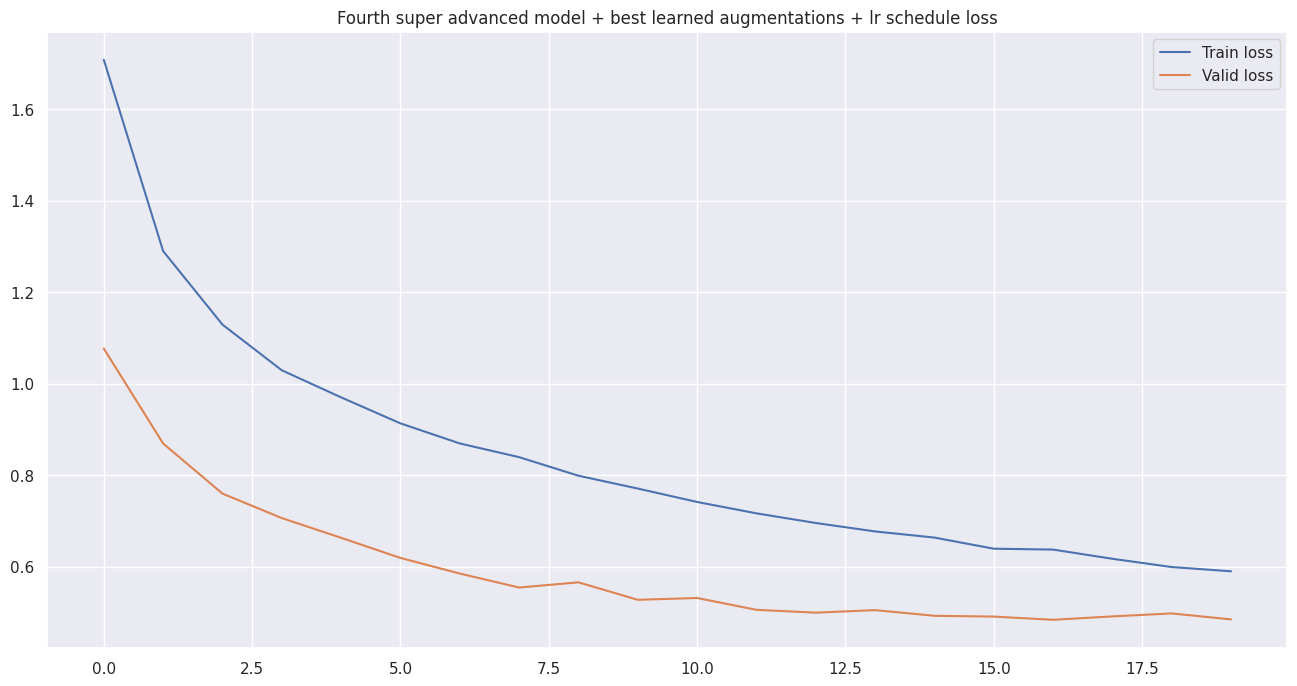

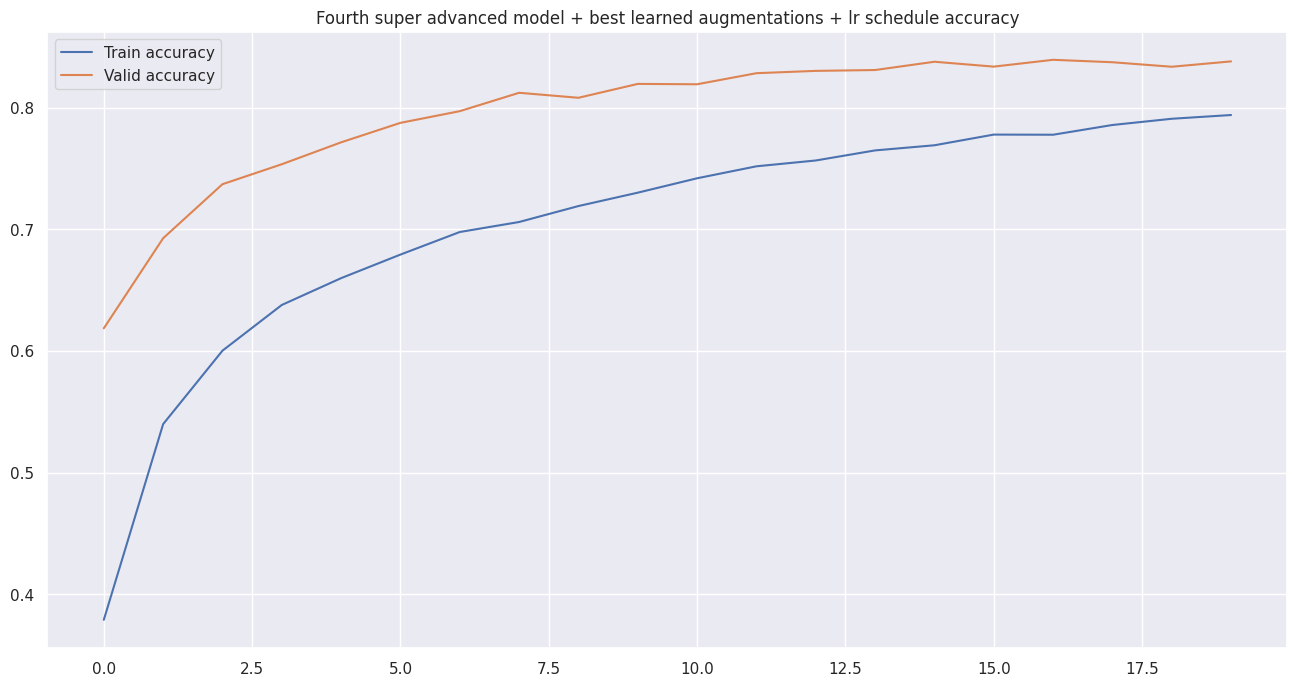

In [114]:
from torch.optim.lr_scheduler import StepLR

torch.manual_seed(42)
np.random.seed(42)

model = FourthModel().to(device)

optimizer = Adam(model.parameters(), lr=1e-3)

scheduler = StepLR(optimizer, step_size=25, gamma=0.1)

fit(
    model,
    train_loader_augs2, valid_loader_augs2,
    optimizer, loss_fn, device, 20, 'Fourth super advanced model + best learned augmentations + lr schedule', scheduler
)

In [115]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def predict_greedy(model: nn.Module, loader: DataLoader, device: torch.device):
    model.eval()

    prediction = []

    for x, _ in tqdm(loader):
        output = model(x.to(device)).cpu()

        prediction.append(torch.argmax(output, dim=1))

    prediction = torch.cat(prediction)

    return prediction

In [116]:
def get_labels(loader):
    labels = []

    for _, y in tqdm(loader):
        labels.append(y)

    return torch.cat(labels, dim=0)

In [117]:
prediction = predict_greedy(model, valid_loader, device)
labels = get_labels(valid_loader)

100%|██████████| 79/79 [00:03<00:00, 25.65it/s]


In [118]:
torch.mean((prediction == labels).to(torch.float32))

tensor(0.8214)

In [119]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader


@torch.inference_mode()
def predict_tta(model: nn.Module, loader: DataLoader, device: torch.device, iterations: int=2):
    model.eval()

    prediction = []

    for iteration in range(iterations):
        single_prediction = []

        for x, _ in tqdm(loader):
            output = model(x.to(device)).cpu()

            single_prediction.append(output)

        prediction.append(torch.vstack(single_prediction))

    prediction = torch.argmax(torch.mean(torch.stack(prediction), dim=0), dim=1)

    return prediction

In [121]:
transforms = T.Compose(
    [
        T.RandomResizedCrop(size=32, scale=(0.8, 1.2)),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        T.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
    ]
)

valid_dataset = CIFAR10('datasets/cifar', train=False, transform=transforms)

valid_loader_augs_tta = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [122]:
prediction_tta = predict_tta(model, valid_loader_augs_tta, device, iterations=20)

100%|██████████| 79/79 [00:05<00:00, 15.80it/s]


In [123]:
torch.mean((prediction_tta == labels).to(torch.float32))

tensor(0.8382)

### Предобученные модели

In [124]:
# https://pytorch.org/vision/stable/models.html
from torchvision.models import alexnet
from torchvision.models import vgg11_bn
from torchvision.models import googlenet
from torchvision.models import resnet18

In [125]:
model = alexnet()

model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [126]:
sum(p.numel() for p in model.classifier.parameters())

58631144

In [127]:
model = vgg11_bn()

model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(ke

In [128]:
sum(p.numel() for p in model.parameters())

132868840

In [129]:
model = googlenet(init_weights=False)

model

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

In [130]:
sum(p.numel() for p in model.parameters())

13004888

In [131]:
model = resnet18()

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [132]:
sum(p.numel() for p in model.parameters())

11689512

In [133]:
from torchvision.datasets import OxfordIIITPet

dataset = OxfordIIITPet('datasets/pets', download=True)

100%|██████████| 792M/792M [00:36<00:00, 22.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.6MB/s]


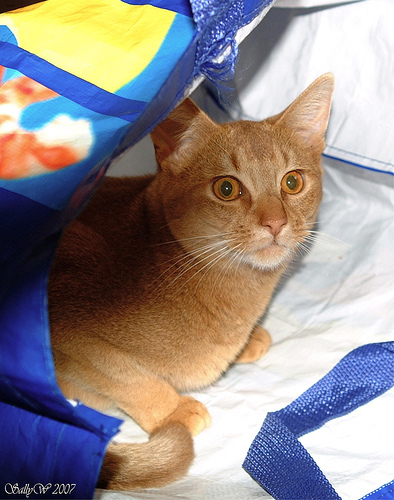

In [134]:
dataset[0][0]

In [135]:
len(dataset)

3680

In [136]:
dataset.classes

['Abyssinian',
 'American Bulldog',
 'American Pit Bull Terrier',
 'Basset Hound',
 'Beagle',
 'Bengal',
 'Birman',
 'Bombay',
 'Boxer',
 'British Shorthair',
 'Chihuahua',
 'Egyptian Mau',
 'English Cocker Spaniel',
 'English Setter',
 'German Shorthaired',
 'Great Pyrenees',
 'Havanese',
 'Japanese Chin',
 'Keeshond',
 'Leonberger',
 'Maine Coon',
 'Miniature Pinscher',
 'Newfoundland',
 'Persian',
 'Pomeranian',
 'Pug',
 'Ragdoll',
 'Russian Blue',
 'Saint Bernard',
 'Samoyed',
 'Scottish Terrier',
 'Shiba Inu',
 'Siamese',
 'Sphynx',
 'Staffordshire Bull Terrier',
 'Wheaten Terrier',
 'Yorkshire Terrier']

In [137]:
num_classes = len(dataset.classes)

num_classes

37

In [138]:
transform = T.Compose(
    [
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]
)

train_dataset = OxfordIIITPet('datasets/pets', transform=transform)
valid_dataset = OxfordIIITPet('datasets/pets', transform=transform, split='test')

In [139]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=8, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

In [140]:
from torchvision.models import AlexNet_Weights, ResNet18_Weights

In [141]:
model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)

model

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 175MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [142]:
model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)

model

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

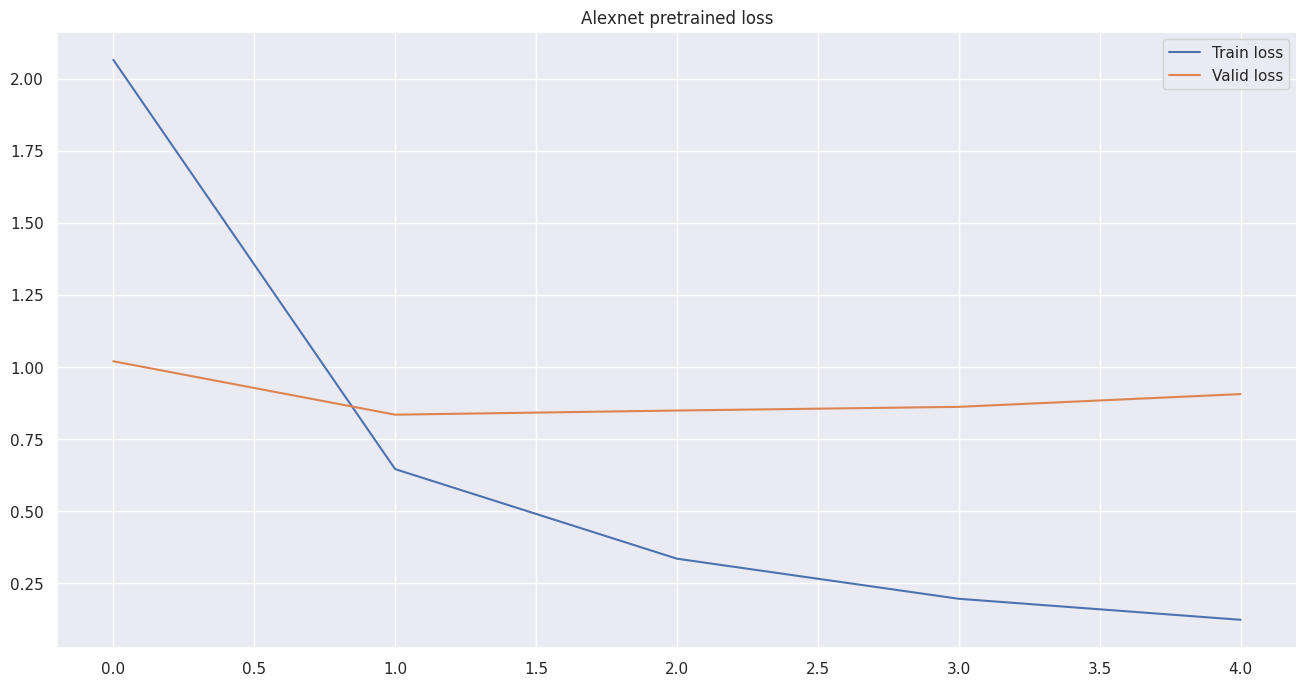

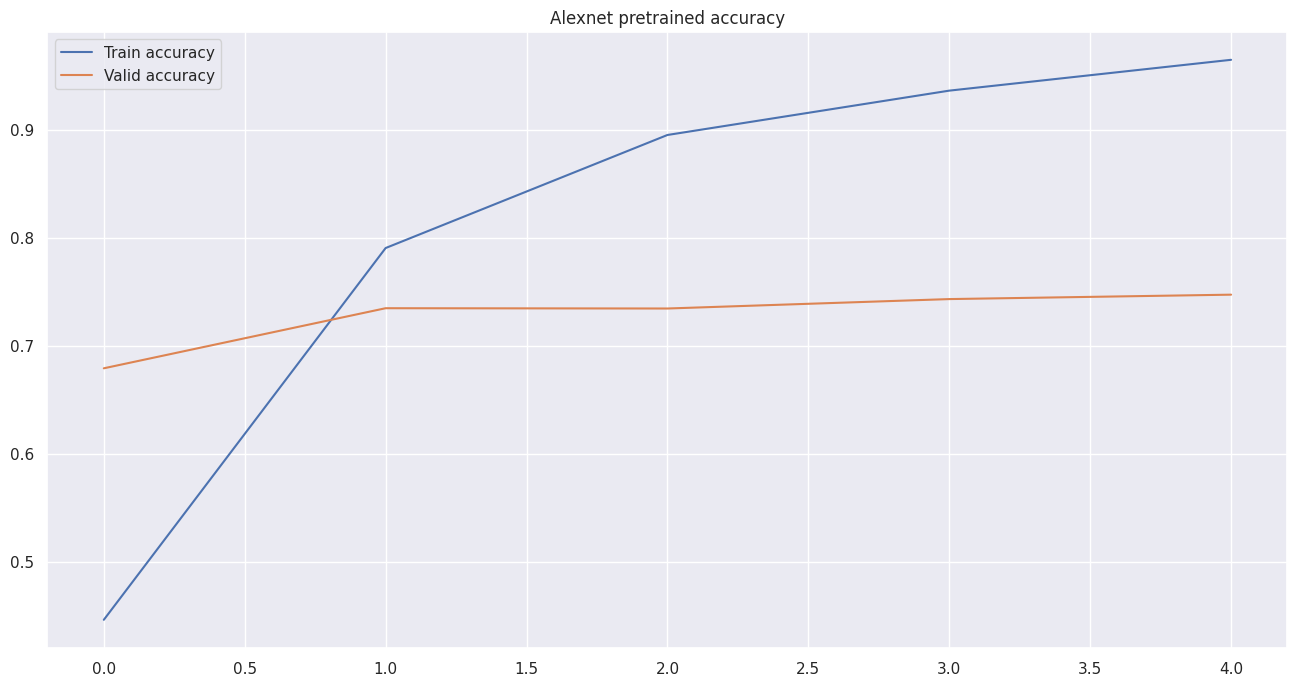

In [144]:
from torch.optim import Adam

loss_fn = torch.nn.CrossEntropyLoss()

model = model.to(device)

model.features.requires_grad_(False)
model.features[8].requires_grad_(True)
model.features[10].requires_grad_(True)

optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)

fit(
    model,
    train_loader, valid_loader,
    optimizer, loss_fn, device, 5, 'Alexnet pretrained'
)

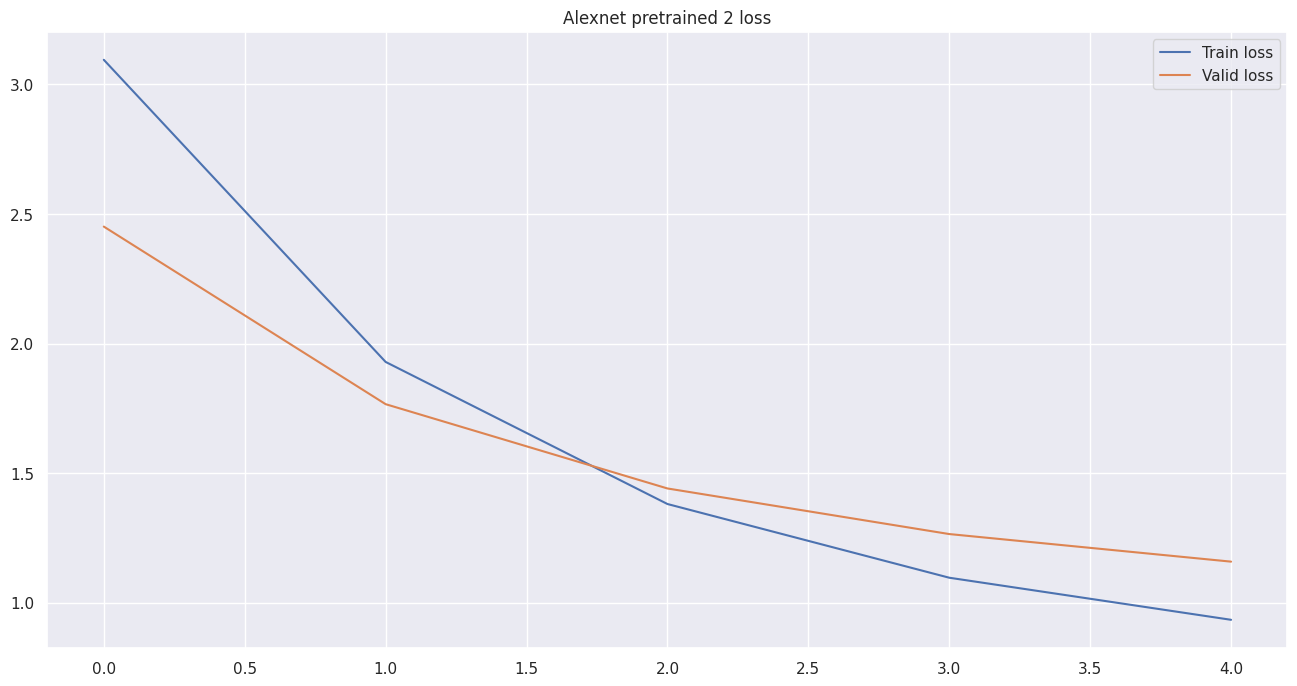

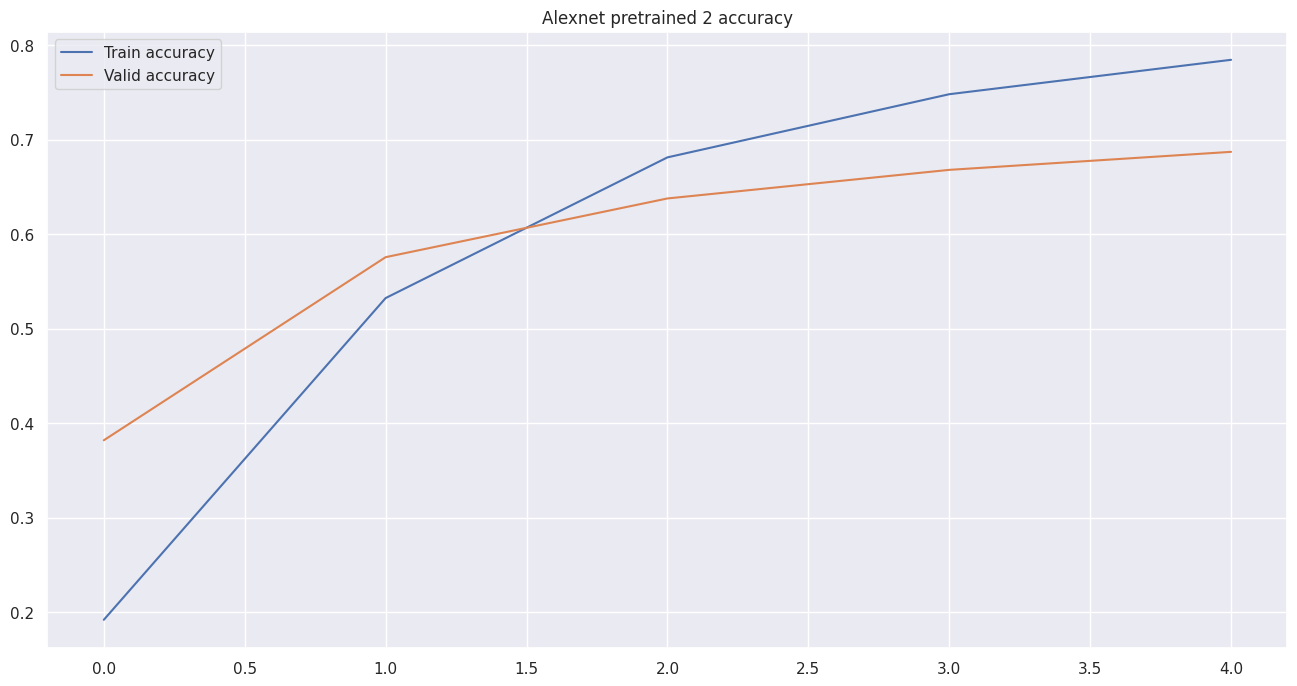

In [146]:
model = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
model.requires_grad_(False)
model.classifier[6] = nn.Linear(in_features=4096, out_features=num_classes)

model = model.to(device)

optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-4)

fit(
    model,
    train_loader, valid_loader,
    optimizer, loss_fn, device, 5, 'Alexnet pretrained 2'
)

In [147]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

model

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 134MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [148]:
model.fc = nn.Linear(in_features=512, out_features=num_classes)

model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

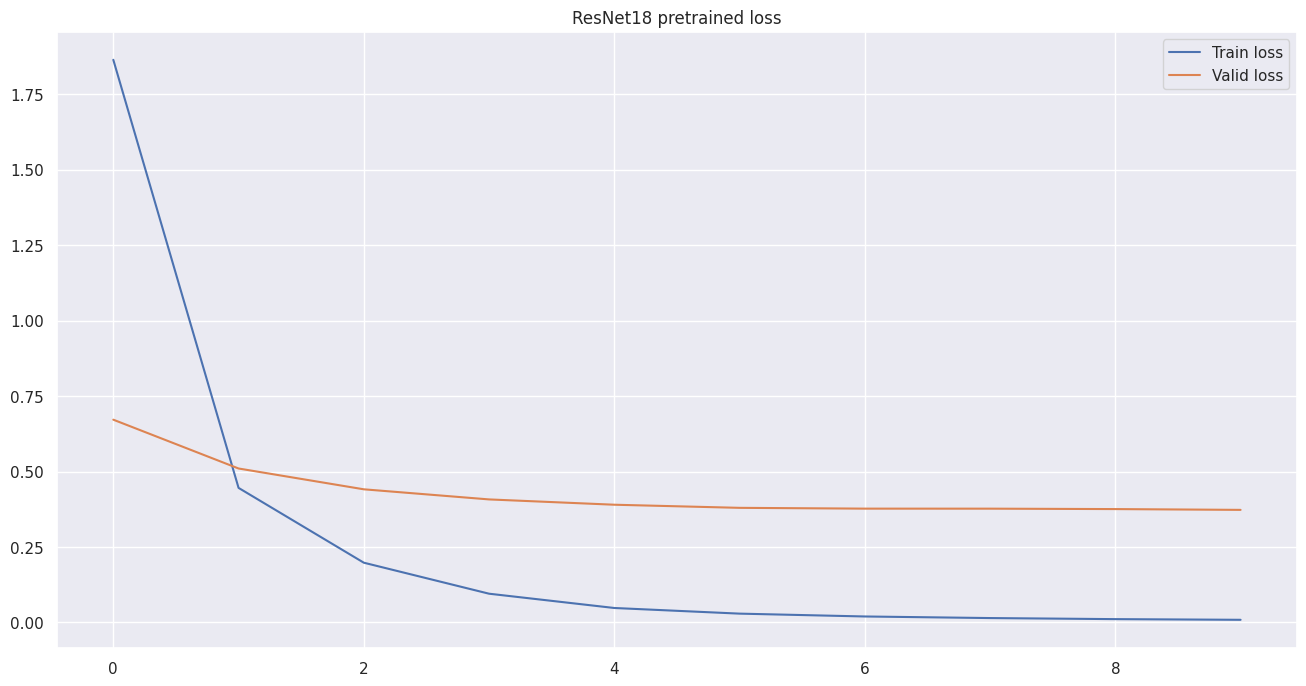

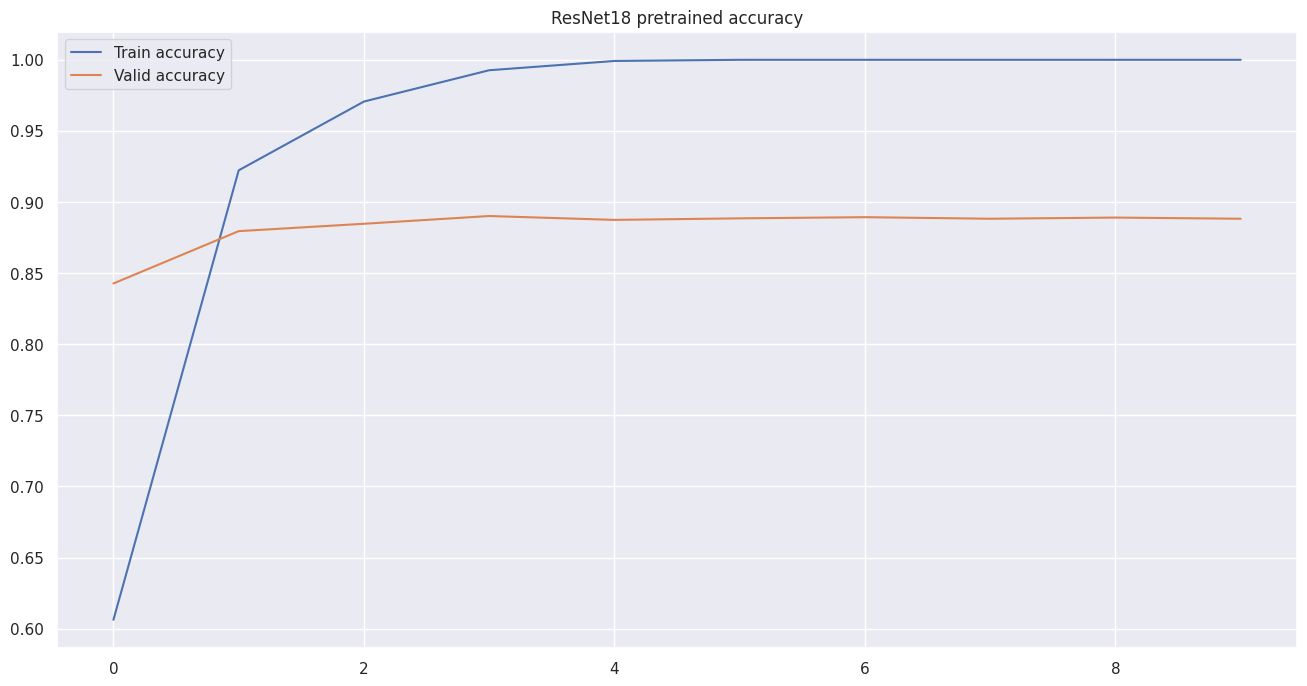

In [149]:
model = model.to(device)

model.requires_grad_(False)
model.layer4.requires_grad_(True)
model.fc.requires_grad_(True)

# optimizer = Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)

optimizer = Adam(
    [
        {'params': model.fc.parameters(), 'lr': 1e-3},
        {'params': model.layer4.parameters(), 'lr': 1e-4}
    ]
)

fit(
    model,
    train_loader, valid_loader,
    optimizer, loss_fn, device, 10, 'ResNet18 pretrained'
)